In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Marseille"
away= "Nantes"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Marseille,Nice,2025-01-26,L,A,0,2,-2,71,0,...,0.7,1.0,-0.8,-0.8,-0.7,0.05,1,1.3,0.26,-0.7
19,Marseille,Lyon,2025-02-02,W,H,3,2,1,63,0,...,3.0,2.2,-0.2,-0.2,0.0,0.16,0,2.1,0.27,0.1
20,Marseille,Angers,2025-02-09,W,A,2,0,2,78,0,...,1.9,2.0,-0.4,-0.4,0.1,0.14,0,0.0,NaN,0.0
21,Marseille,Saint-Étienne,2025-02-15,W,H,5,1,4,70,1,...,4.6,4.2,-1.1,-1.3,-1.6,0.22,0,1.4,0.72,0.4
22,Marseille,Auxerre,2025-02-22,L,A,0,3,-3,79,0,...,0.4,1.2,-0.7,-0.7,-0.4,0.08,0,2.7,0.36,-0.3


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Nice,Marseille,2025-01-26,W,H,2,0,2,29,0,...,0.9,0.6,0.8,0.8,0.1,0.09,0,0.5,0.08,0.5
19,Lyon,Marseille,2025-02-02,L,A,2,3,-1,37,1,...,0.6,0.4,0.3,0.1,0.4,0.10,0,4.2,0.40,1.2
20,Angers,Marseille,2025-02-09,L,H,0,2,-2,22,0,...,0.2,0.4,-0.5,-0.5,-0.2,0.10,0,2.6,0.33,0.6
21,Saint-Étienne,Marseille,2025-02-15,L,A,1,5,-4,30,0,...,1.0,0.8,0.0,0.0,0.0,0.15,0,5.5,0.38,0.5
22,Auxerre,Marseille,2025-02-22,W,H,3,0,3,21,1,...,0.8,0.7,1.0,0.8,1.2,0.15,0,0.2,0.11,0.2


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Nantes,Lyon,2025-01-26,D,H,1,1,0,38,0,...,0.9,0.8,-0.2,-0.2,0.1,0.18,0,1.0,0.24,0.0
19,Nantes,Reims,2025-02-02,W,A,2,1,1,45,0,...,2.0,0.5,0.0,0.0,0.0,0.21,0,0.6,0.29,0.6
20,Nantes,Brest,2025-02-07,L,H,0,2,-2,58,0,...,0.7,1.1,-1.1,-1.1,-0.7,0.07,1,1.9,0.32,-0.1
21,Nantes,Monaco,2025-02-15,L,A,1,7,-6,35,0,...,1.3,0.4,-0.4,-0.4,-0.3,0.24,0,5.2,0.40,-1.8
22,Nantes,Lens,2025-02-23,W,H,3,1,2,35,1,...,2.6,2.1,-0.9,-1.2,-1.6,0.23,0,1.4,0.21,0.4


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
18,Lyon,Nantes,2025-01-26,D,A,1,1,0,62,0,...,1.1,2.2,-0.1,-0.1,-0.1,0.07,1,1.4,0.28,0.4
19,Reims,Nantes,2025-02-02,L,H,1,2,-1,55,0,...,0.7,1.1,-1.0,-1.0,-0.7,0.08,0,2.4,0.45,0.4
20,Brest,Nantes,2025-02-07,W,A,2,0,2,42,0,...,2.5,1.9,-0.5,-0.5,-0.5,0.25,0,0.4,0.19,0.4
21,Monaco,Nantes,2025-02-15,W,H,7,1,6,65,1,...,3.3,3.7,2.6,2.4,1.7,0.17,0,1.2,0.58,0.2
22,Lens,Nantes,2025-02-23,L,A,1,3,-2,65,1,...,0.5,0.8,-0.6,-1.0,-0.5,0.08,0,3.1,0.33,0.1


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,0,0,0,71,0,13,2,15.4,9,69.2,...,-0.4,-0.4,0.7,1.0,-0.8,-0.8,-0.7,0.05,1,0
19,3,0,0,63,0,8,3,37.5,5,62.5,...,1.5,2.3,3.0,2.2,-0.2,-0.2,0.0,0.16,0,3
20,2,0,0,78,0,15,9,60.0,6,40.0,...,1.9,1.9,1.9,2.0,-0.4,-0.4,0.1,0.14,0,2
21,4,1,0,70,1,15,12,80.0,3,20.0,...,5.0,4.2,4.6,4.2,-1.1,-1.3,-1.6,0.22,0,5
22,0,0,0,79,0,18,5,27.8,13,72.2,...,-1.3,-0.5,0.4,1.2,-0.7,-0.7,-0.4,0.08,0,0


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,2,0,0,29,0,14,5,35.7,9,64.3,...,0.4,0.4,0.9,0.6,0.8,0.8,0.1,0.09,0,2
19,1,1,0,37,1,13,3,23.1,8,61.5,...,-1.5,-2.3,0.6,0.4,0.3,0.1,0.4,0.10,0,2
20,0,0,0,22,0,14,4,28.6,9,64.3,...,-1.9,-1.9,0.2,0.4,-0.5,-0.5,-0.2,0.10,0,0
21,1,0,0,30,0,12,3,25.0,9,75.0,...,-5.0,-4.2,1.0,0.8,0.0,0.0,0.0,0.15,0,1
22,2,1,0,21,1,18,7,38.9,9,50.0,...,1.3,0.5,0.8,0.7,1.0,0.8,1.2,0.15,0,3


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,38,0,18,9,50.0,9,50.0,...,0.1,0.1,0.9,0.8,-0.2,-0.2,0.1,0.18,0,1
19,2,0,0,45,0,8,7,87.5,1,12.5,...,0.9,0.9,2.0,0.5,0.0,0.0,0.0,0.21,0,2
20,0,0,0,58,0,18,5,27.8,13,72.2,...,-1.4,-1.4,0.7,1.1,-1.1,-1.1,-0.7,0.07,1,0
21,1,0,0,35,0,17,7,41.2,9,52.9,...,-3.0,-2.2,1.3,0.4,-0.4,-0.4,-0.3,0.24,0,1
22,2,1,0,35,1,34,16,47.1,16,47.1,...,2.3,2.2,2.6,2.1,-0.9,-1.2,-1.6,0.23,0,3


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
18,1,0,0,62,0,12,3,25.0,9,75.0,...,-0.1,-0.1,1.1,2.2,-0.1,-0.1,-0.1,0.07,1,1
19,0,0,0,55,0,23,9,39.1,13,56.5,...,-0.9,-0.9,0.7,1.1,-1.0,-1.0,-0.7,0.08,0,1
20,2,0,0,42,0,10,2,20.0,7,70.0,...,1.4,1.4,2.5,1.9,-0.5,-0.5,-0.5,0.25,0,2
21,6,1,0,65,1,12,8,66.7,3,25.0,...,3.0,2.2,3.3,3.7,2.6,2.4,1.7,0.17,0,7
22,0,1,0,65,1,22,6,27.3,16,72.7,...,-2.3,-2.2,0.5,0.8,-0.6,-1.0,-0.5,0.08,0,1


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,12,0,0.0,0,3,23.2,0,NaN,0,0,...,3,1,14,35,17,2,1.3,0.26,-0.7,2
19,8,4,50.0,1,2,13.8,0,0.0,0,0,...,3,8,8,26,16,1,2.1,0.27,0.1,2
20,7,0,0.0,0,0,17.0,0,NaN,0,0,...,2,6,4,20,10,1,0.0,NaN,0.0,0
21,2,0,0.0,0,0,NaN,0,NaN,0,0,...,2,8,10,23,8,0,1.4,0.72,0.4,1
22,11,0,0.0,1,3,23.4,0,0.0,0,1,...,1,4,0,13,18,1,2.7,0.36,-0.3,3


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
18,23,2,8.7,0,1,15.2,0,NaN,0,0,...,8,11,17,43,36,0,0.5,0.08,0.5,0
19,13,0,0.0,0,2,24.0,0,NaN,0,0,...,0,5,12,23,34,0,4.2,0.40,1.2,3
20,20,0,0.0,0,2,15.0,0,NaN,0,1,...,4,11,11,26,26,0,2.6,0.33,0.6,2
21,23,1,4.3,1,0,7.5,0,0.0,0,0,...,7,14,7,17,38,1,5.5,0.38,0.5,5
22,12,2,16.7,0,2,15.8,0,NaN,0,0,...,2,3,7,33,35,0,0.2,0.11,0.2,0


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,20,2,10.0,0,0,4.6,0,NaN,0,0,...,3,7,5,23,33,0,1.3,0.22,1.3,0
1,28,1,3.6,0,0,5.8,0,NaN,0,0,...,5,10,10,31,41,0,0.3,0.11,0.3,0
2,27,3,11.1,0,1,9.3,0,NaN,0,0,...,2,12,8,32,46,1,0.5,0.14,-0.5,1
3,11,0,0.0,0,0,15.3,0,NaN,0,0,...,2,1,5,26,30,0,0.9,0.23,-1.1,2
4,12,2,16.7,1,0,10.7,0,0.0,0,0,...,1,3,5,25,21,0,0.6,0.00,-0.4,1


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,16,1,6.3,0,0,10.3,0,NaN,0,0,...,3,3,8,28,20,0,0.8,0.40,0.8,0
1,15,2,13.3,0,1,15.0,0,NaN,0,0,...,1,7,10,32,31,1,1.4,0.27,-0.6,2
2,9,1,11.1,1,2,19.4,0,0.0,0,0,...,1,7,4,19,12,0,1.5,0.16,-1.5,3
3,17,1,5.9,0,1,16.0,0,NaN,0,0,...,7,6,3,18,21,0,2.1,0.38,1.1,1
4,12,2,16.7,0,0,7.5,0,NaN,0,0,...,4,8,10,33,21,1,1.3,0.43,0.3,1


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,11,7,61.1,1,0,0,9,11,47
19,12,11,52.2,4,0,0,13,9,43
20,11,7,61.1,2,0,0,8,10,43
21,9,5,64.3,1,0,0,14,8,50
22,10,9,52.6,3,1,1,13,7,51


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,7,11,38.9,1,0,0,12,8,46
19,11,12,47.8,1,0,0,10,12,32
20,7,11,38.9,1,0,0,10,7,38
21,5,9,35.7,1,0,0,9,13,36
22,9,10,47.4,1,0,0,9,11,57


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,4,8,33.3,3,0,0,14,10,44
19,8,14,36.4,3,0,0,10,13,35
20,17,22,43.6,3,0,0,15,13,39
21,16,12,57.1,1,1,0,9,18,33
22,13,12,52.0,2,0,0,13,16,44


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
18,8,4,66.7,1,0,0,11,14,40
19,14,8,63.6,4,1,1,14,10,41
20,22,17,56.4,2,0,0,13,14,45
21,12,16,42.9,1,0,0,18,7,52
22,12,13,48.0,4,1,0,18,10,42


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,0,0,0,71,0,13,2,15.4,9,69.2,...,-0.025,1.567110,0.175,1.244655,0.1525,0.045000,0.25,0.50000,2.25,1.892969
19,3,0,0,63,0,8,3,37.5,5,62.5,...,-0.175,1.617354,-0.100,1.298717,0.1325,0.069462,0.50,0.57735,2.00,2.160247
20,2,0,0,78,0,15,9,60.0,6,40.0,...,-0.675,0.991211,-0.425,0.946485,0.1175,0.047170,0.50,0.57735,1.50,1.290994
21,4,1,0,70,1,15,12,80.0,3,20.0,...,-0.850,0.806226,-0.550,0.785281,0.1200,0.048305,0.25,0.50000,1.50,1.290994
22,0,0,0,79,0,18,5,27.8,13,72.2,...,-0.675,0.485627,-0.550,0.785281,0.1425,0.070415,0.25,0.50000,2.50,2.081666


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,2,0,0,29,0,14,5,35.7,9,64.3,...,0.125,0.411299,0.375,0.330404,0.1475,0.037749,0.25,0.5,1.00,0.000000
19,1,1,0,37,1,13,3,23.1,8,61.5,...,0.425,0.330404,0.400,0.294392,0.1350,0.047958,0.25,0.5,1.25,0.500000
20,0,0,0,22,0,14,4,28.6,9,64.3,...,0.300,0.336650,0.350,0.264575,0.1325,0.049917,0.25,0.5,1.50,0.577350
21,1,0,0,30,0,12,3,25.0,9,75.0,...,0.125,0.531507,0.125,0.250000,0.1075,0.022174,0.25,0.5,1.25,0.957427
22,2,1,0,21,1,18,7,38.9,9,50.0,...,0.100,0.535413,0.075,0.250000,0.1100,0.027080,0.00,0.0,1.25,0.957427


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,13,0,0.0,0,1,15.5,0,0.0,0,0,...,0.50,1.0,1.475,0.880814,0.3100,0.125167,-5.250000e-01,0.953502,2.00,1.414214
19,28,1,3.6,0,0,6.5,0,0.0,0,0,...,0.50,1.0,1.175,0.745542,0.3000,0.129872,-7.500000e-02,0.434933,1.25,0.500000
20,18,1,5.6,0,0,10.0,0,0.0,0,0,...,0.50,1.0,1.000,0.787401,0.2625,0.092150,-2.775558e-17,0.535413,1.25,0.500000
21,22,0,0.0,1,0,8.7,0,0.0,0,0,...,0.00,0.0,0.950,0.695222,0.2500,0.074386,-5.000000e-02,0.532291,1.25,0.500000
22,19,0,0.0,1,0,10.8,0,0.0,0,0,...,0.25,0.5,2.175,2.088660,0.3125,0.067020,-3.250000e-01,1.030776,2.75,2.872281


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,21,2,9.5,0,0,5.8,0,0.0,0,0,...,1.00,1.414214,0.900,0.141421,0.1575,0.057373,-0.350,0.580230,1.25,0.500000
19,10,0,0.0,0,0,16.0,0,0.0,0,0,...,1.00,1.414214,1.025,0.287228,0.1950,0.078528,-0.225,0.694622,1.25,0.500000
20,33,2,6.1,0,2,12.8,0,0.0,0,0,...,1.00,1.414214,1.350,0.754983,0.2850,0.115614,-0.150,0.754983,1.50,0.577350
21,6,0,0.0,0,0,8.0,0,0.0,0,0,...,0.75,1.500000,1.250,0.869866,0.2800,0.120277,0.250,0.300000,1.00,0.816497
22,9,1,11.1,1,5,20.9,0,0.0,0,0,...,0.00,0.000000,1.350,0.822598,0.3750,0.174069,0.350,0.100000,1.00,0.816497


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,38,0,18,9,50.0,9,50.0,...,0.075,0.767572,0.075,0.991211,0.1075,0.045000,0.00,0.0,1.25,0.500000
19,2,0,0,45,0,8,7,87.5,1,12.5,...,0.050,0.776745,0.050,0.988264,0.1350,0.047958,0.00,0.0,1.25,0.500000
20,0,0,0,58,0,18,5,27.8,13,72.2,...,0.175,0.694622,0.150,0.946925,0.1600,0.055976,0.00,0.0,1.50,0.577350
21,1,0,0,35,0,17,7,41.2,9,52.9,...,-0.400,0.483046,-0.375,0.499166,0.1575,0.060759,0.25,0.5,1.00,0.816497
22,2,1,0,35,1,34,16,47.1,16,47.1,...,-0.425,0.478714,-0.225,0.359398,0.1750,0.074162,0.25,0.5,1.00,0.816497


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
18,1,0,0,62,0,12,3,25.0,9,75.0,...,0.150,1.408309,-0.175,1.024288,0.1375,0.076322,0.25,0.50000,2.00,1.414214
19,0,0,0,55,0,23,9,39.1,13,56.5,...,-0.375,0.704154,-0.475,0.623832,0.1175,0.082209,0.50,0.57735,1.25,0.500000
20,2,0,0,42,0,10,2,20.0,7,70.0,...,-0.575,0.750000,-0.425,0.585235,0.1150,0.083467,0.50,0.57735,1.25,0.500000
21,6,1,0,65,1,12,8,66.7,3,25.0,...,-0.350,0.519615,-0.275,0.403113,0.1175,0.088459,0.25,0.50000,1.25,0.500000
22,0,1,0,65,1,22,6,27.3,16,72.7,...,0.200,1.512173,0.100,1.095445,0.1425,0.084607,0.25,0.50000,2.75,2.872281


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,12,0,0.0,0,3,23.2,0,0.0,0,0,...,0.25,0.500000,1.275,0.377492,0.487500,0.289065,2.750000e-01,0.377492,1.00,0.000000
19,8,4,50.0,1,2,13.8,0,0.0,0,0,...,0.75,0.957427,1.200,0.316228,0.472500,0.301924,-5.000000e-02,0.532291,1.25,0.500000
20,7,0,0.0,0,0,17.0,0,0.0,0,0,...,0.75,0.957427,1.500,0.469042,0.310000,0.053541,4.163336e-17,0.535413,1.50,0.577350
21,2,0,0.0,0,0,0.0,0,0.0,0,0,...,1.00,0.816497,1.100,0.867948,0.290000,0.043589,-1.500000e-01,0.369685,1.25,0.957427
22,11,0,0.0,1,3,23.4,0,0.0,0,1,...,1.00,0.816497,1.200,0.875595,0.416667,0.262742,-5.000000e-02,0.465475,1.25,0.957427


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
18,23,2,8.7,0,1,15.2,0,0.0,0,0,...,0.75,0.50000,2.375,1.508587,0.3725,0.168003,0.125,0.419325,2.25,1.892969
19,13,0,0.0,0,2,24.0,0,0.0,0,0,...,0.50,0.57735,2.175,1.734695,0.2850,0.213151,0.175,0.457347,2.00,2.160247
20,20,0,0.0,0,2,15.0,0,0.0,0,1,...,0.50,0.57735,2.100,1.602082,0.2450,0.150000,0.600,0.408248,1.50,1.290994
21,23,1,4.3,1,0,7.5,0,0.0,0,0,...,0.25,0.50000,2.150,1.617611,0.2425,0.147958,0.650,0.387298,1.50,1.290994
22,12,2,16.7,0,2,15.8,0,0.0,0,0,...,0.25,0.50000,3.200,2.155613,0.2975,0.147958,0.700,0.336650,2.50,2.081666


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
18,11,7,61.1,1,0,0,9,11,47,7.50,...,0.25,0.5,0.0,0.0,13.00,0.816497,9.75,3.500000,44.25,3.304038
19,12,11,52.2,4,0,0,13,9,43,9.25,...,0.00,0.0,0.0,0.0,11.75,1.892969,10.50,3.316625,46.00,1.825742
20,11,7,61.1,2,0,0,8,10,43,10.00,...,0.00,0.0,0.0,0.0,12.00,2.000000,11.25,2.061553,44.75,1.707825
21,9,5,64.3,1,0,0,14,8,50,10.75,...,0.00,0.0,0.0,0.0,10.75,2.629956,11.00,2.160247,44.50,1.914854
22,10,9,52.6,3,1,1,13,7,51,10.75,...,0.00,0.0,0.0,0.0,11.00,2.943920,9.50,1.290994,45.75,3.403430


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
18,7,11,38.9,1,0,0,12,8,46,7.00,...,0.0,0.0,0.0,0.0,10.00,3.366502,12.50,0.577350,40.50,4.795832
19,11,12,47.8,1,0,0,10,12,32,6.75,...,0.0,0.0,0.0,0.0,10.75,3.403430,11.25,2.217356,41.75,5.560276
20,7,11,38.9,1,0,0,10,7,38,7.75,...,0.0,0.0,0.0,0.0,11.75,1.707825,11.25,2.217356,40.25,7.410578
21,5,9,35.7,1,0,0,9,13,36,7.50,...,0.0,0.0,0.0,0.0,11.50,1.914854,10.00,2.943920,38.00,5.887841
22,9,10,47.4,1,0,0,9,11,57,7.50,...,0.0,0.0,0.0,0.0,10.25,1.258306,10.00,2.943920,38.00,5.887841


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
18,4,8,33.3,3,0,0,14,10,44,12.50,...,0.00,0.0,0.0,0.0,13.0,3.162278,9.75,3.304038,40.25,6.075909
19,8,14,36.4,3,0,0,10,13,35,9.75,...,0.00,0.0,0.0,0.0,13.0,3.162278,9.75,3.304038,42.50,5.066228
20,17,22,43.6,3,0,0,15,13,39,10.00,...,0.00,0.0,0.0,0.0,13.0,3.162278,11.50,2.380476,41.75,6.075909
21,16,12,57.1,1,1,0,9,18,33,10.00,...,0.00,0.0,0.0,0.0,12.5,2.380476,11.25,2.061553,41.75,6.075909
22,13,12,52.0,2,0,0,13,16,44,11.25,...,0.25,0.5,0.0,0.0,12.0,2.943920,13.50,3.316625,37.75,4.856267


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
18,8,4,66.7,1,0,0,11,14,40,15.75,...,0.00,0.0,0.00,0.0,9.75,3.304038,12.75,3.095696,45.5,4.041452
19,14,8,63.6,4,1,1,14,10,41,15.25,...,0.00,0.0,0.00,0.0,10.00,3.366502,13.00,3.162278,43.5,4.358899
20,22,17,56.4,2,0,0,13,14,45,14.75,...,0.25,0.5,0.25,0.5,12.00,2.449490,13.00,3.162278,41.5,2.380476
21,12,16,42.9,1,0,0,18,7,52,17.00,...,0.25,0.5,0.25,0.5,11.75,2.217356,12.25,2.061553,41.5,2.380476
22,12,13,48.0,4,1,0,18,10,42,14.00,...,0.25,0.5,0.25,0.5,14.00,2.943920,11.25,3.403430,44.5,5.446712


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,79,0,18,5,27.8,13,72.2,...,0.5,2.175,2.08866,0.3125,0.06702,-0.325,1.030776,2.75,2.872281,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,3,2,0,50,2,25,8,32.0,15,60.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,2
1,2,0,0,66,0,11,5,45.5,6,54.5,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,3
2,2,0,0,76,0,15,5,33.3,7,46.7,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,H,2
3,2,0,0,56,0,14,6,42.9,8,57.1,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,A,3
4,3,0,0,37,0,15,5,33.3,9,60.0,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,A,0


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,11,0,0.0,1,3,23.4,0,0.0,0,1,...,0.5,0.0,0.0,12.0,2.94392,13.5,3.316625,37.75,4.856267,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,15,0,0.0,1,0,10.0,1,100.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,2
1,14,2,14.3,0,5,19.0,0,0.0,0,1,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,1
2,6,0,0.0,0,4,25.0,0,0.0,0,0,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,H,0
3,9,0,0.0,0,0,4.0,0,0.0,0,0,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,A,2
4,35,3,8.6,1,0,10.8,1,100.0,0,1,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,A,1


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,2,1,0,35,1,34,16,47.1,16,47.1,...,0.5,0.0,0.0,12.0,2.94392,13.5,3.316625,37.75,4.856267,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0,0,0,46,0,15,7,46.7,8,53.3,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,2
1,2,0,0,36,0,20,9,45.0,9,45.0,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,3
2,2,1,0,31,1,14,5,35.7,8,57.1,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,H,1
3,1,0,0,45,0,24,12,50.0,12,50.0,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,A,1
4,1,0,0,50,0,20,9,45.0,11,55.0,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,H,2


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,19,0,0.0,1,0,10.8,0,0.0,0,0,...,0.5,0.0,0.0,12.0,2.94392,13.5,3.316625,37.75,4.856267,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,20,2,10.0,0,0,4.6,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,H,0
1,28,1,3.6,0,0,5.8,0,0.0,0,0,...,0.0,0.0,11.000000,0.000000,14.000000,0.000000,40.0,0.000000,A,1
2,27,3,11.1,0,1,9.3,0,0.0,0,0,...,0.0,0.0,10.000000,1.414214,9.500000,6.363961,42.0,2.828427,H,2
3,11,0,0.0,0,0,15.3,0,0.0,0,0,...,0.0,0.0,11.333333,2.516611,9.666667,4.509250,40.0,4.000000,A,1
4,12,2,16.7,1,0,10.7,0,0.0,0,0,...,0.0,0.0,12.000000,2.449490,8.500000,4.358899,40.5,3.415650,H,2


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

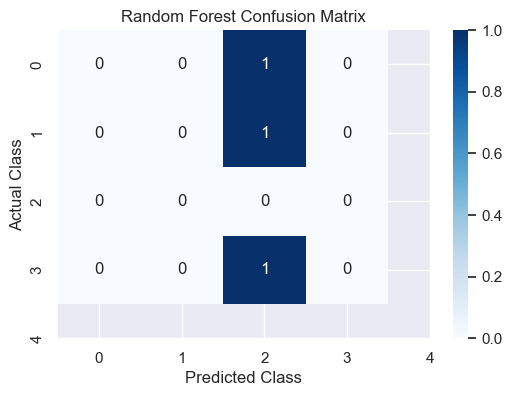

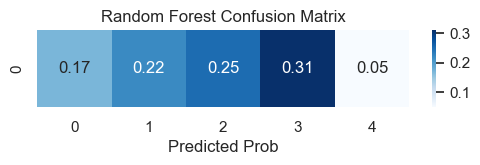

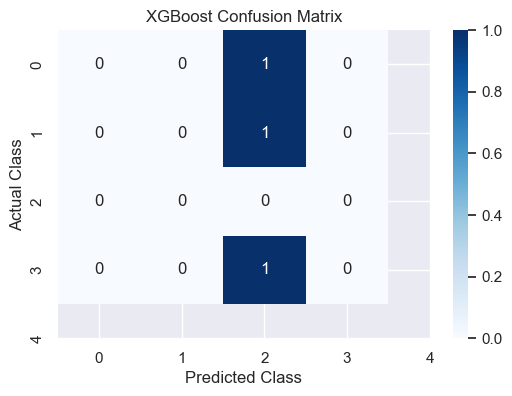

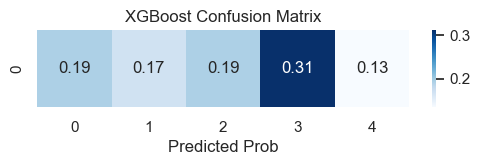

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

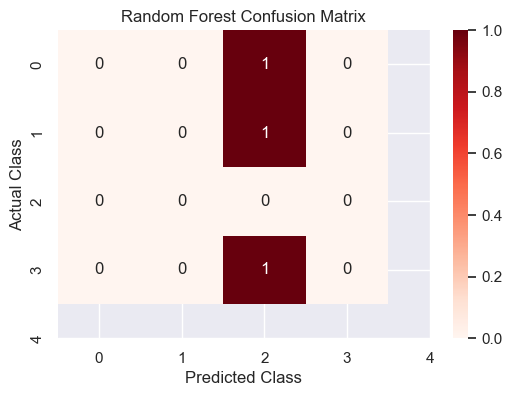

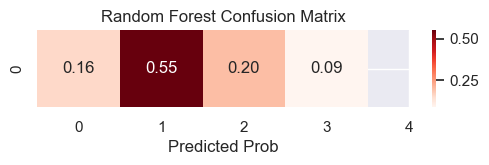

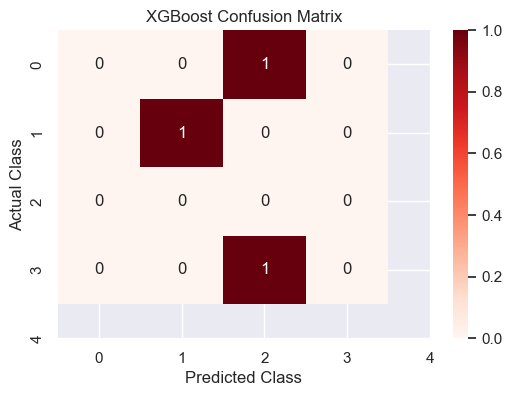

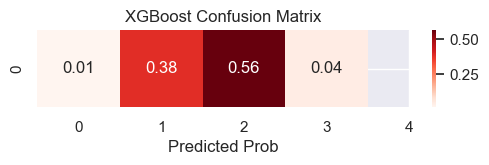

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

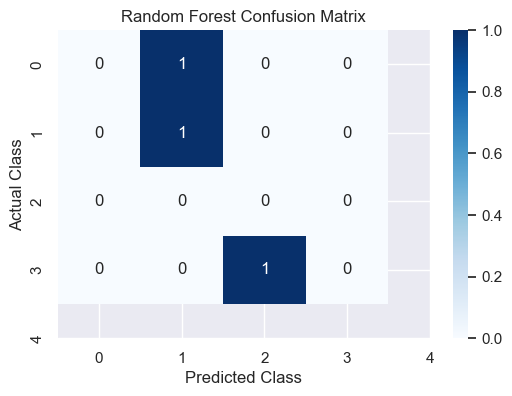

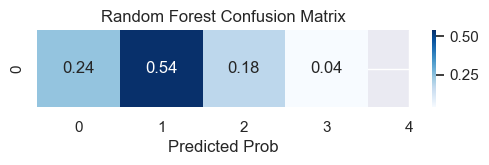

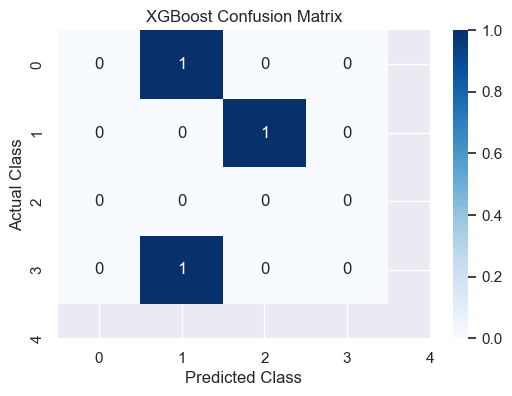

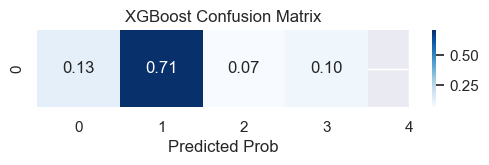

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

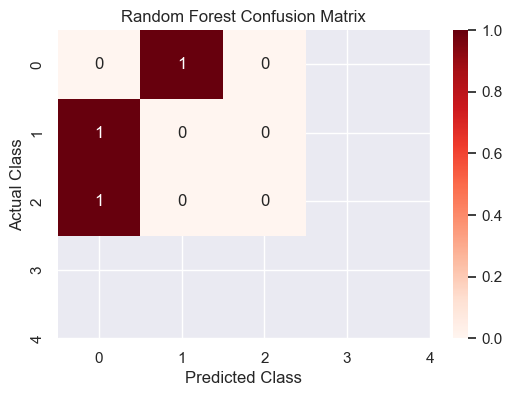

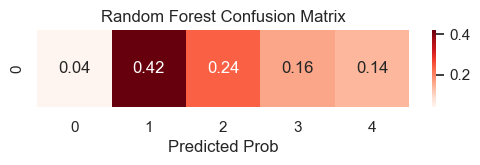

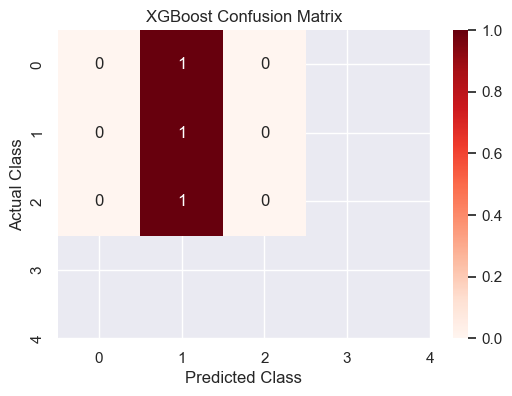

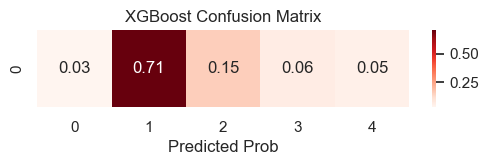

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

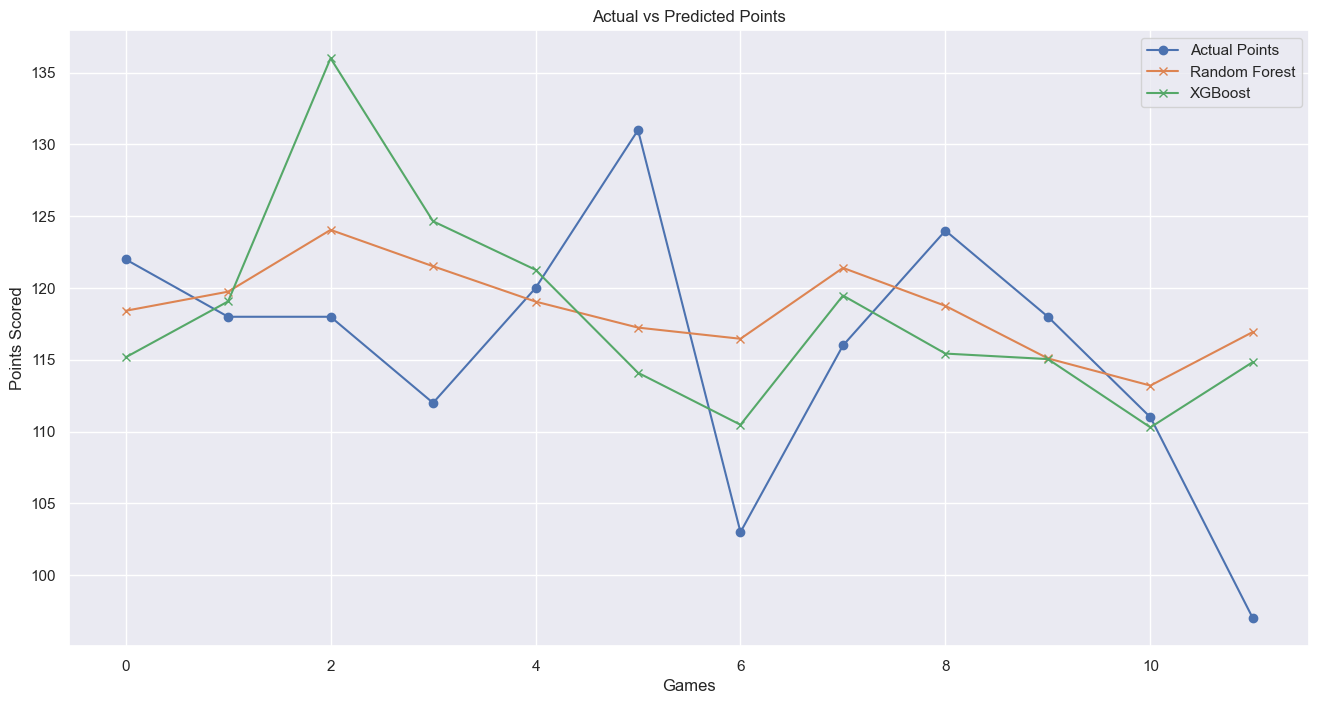

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
